In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from phik import resources, report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

In [173]:
df_test = pd.read_csv('https://media.githubusercontent.com/media/nikitaLar-collab/My_projects/refs/heads/main/test.csv?token=CDZOY2FMJOBAHNHXD7VO3J3KLMT32')

HTTPError: HTTP Error 404: Not Found

In [ ]:
df_train = pd.read_csv('https://media.githubusercontent.com/media/nikitaLar-collab/My_projects/refs/heads/main/train.csv?token=CDZOY2A6XW7JMDKO4SJAFTLKLMT44')

In [ ]:
df = pd.concat([df_test, df_train], ignore_index=True)

In [ ]:
df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,NaN
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,NaN
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
 11  Survived     891 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [ ]:
df= df.dropna(subset = ('Age', 'Fare', 'Survived'))
df= df.drop(columns='Cabin')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 418 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Pclass       714 non-null    int64  
 2   Name         714 non-null    object 
 3   Sex          714 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        714 non-null    int64  
 6   Parch        714 non-null    int64  
 7   Ticket       714 non-null    object 
 8   Fare         714 non-null    float64
 9   Embarked     712 non-null    object 
 10  Survived     714 non-null    float64
dtypes: float64(3), int64(4), object(4)
memory usage: 66.9+ KB


In [ ]:
df['Sex'] = df['Sex'].replace({'male': 1, 'female': 0})

C:\Users\Никита\AppData\Local\Temp\ipykernel_17960\765035159.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'male': 1, 'female': 0})


In [ ]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
418,1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,0.0
419,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,1.0
420,3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,1.0
421,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,1.0
422,5,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1303,886,3,"Rice, Mrs. William (Margaret Norton)",0,39.0,0,5,382652,29.1250,Q,0.0
1304,887,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,S,0.0
1305,888,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,S,1.0
1307,890,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C,1.0


In [ ]:
X = df[['Pclass','Sex', 'Age', 'Fare', 'SibSp', 'Parch']]
y = df['Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict_proba(X_test)

d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
predictions[:5]

array([[0.83191592, 0.16808408],
       [0.52268517, 0.47731483],
       [0.21016337, 0.78983663],
       [0.038175  , 0.961825  ],
       [0.94663239, 0.05336761]])

In [ ]:
model.predict(X_test)

array([0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0.,
       1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 1., 0.,
       1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1.,
       0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1.,
       0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
       0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 1., 1.])

In [ ]:
print(model.score(X_train, y_train))
print(model.score(X_test,y_test))

0.8108581436077058
0.7482517482517482


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, predictions[:,1])

Text(0, 0.5, 'Доля ложноотрицательных классификаций')

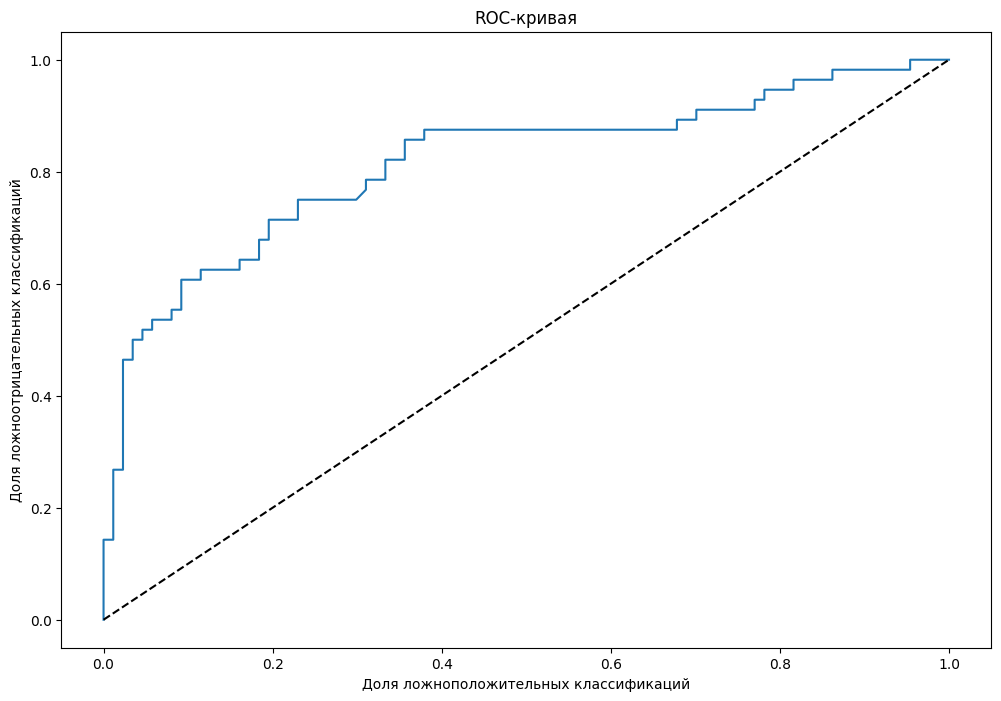

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot( fpr, tpr )
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC-кривая')
plt.xlabel('Доля ложноположительных классификаций')
plt.ylabel('Доля ложноотрицательных классификаций')

In [ ]:
roc_auc_score(y_test, predictions[:, 1])

0.8161945812807883

In [ ]:
df2 = pd.concat([df_test, df_train], ignore_index=True)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
 11  Survived     891 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


<Axes: >

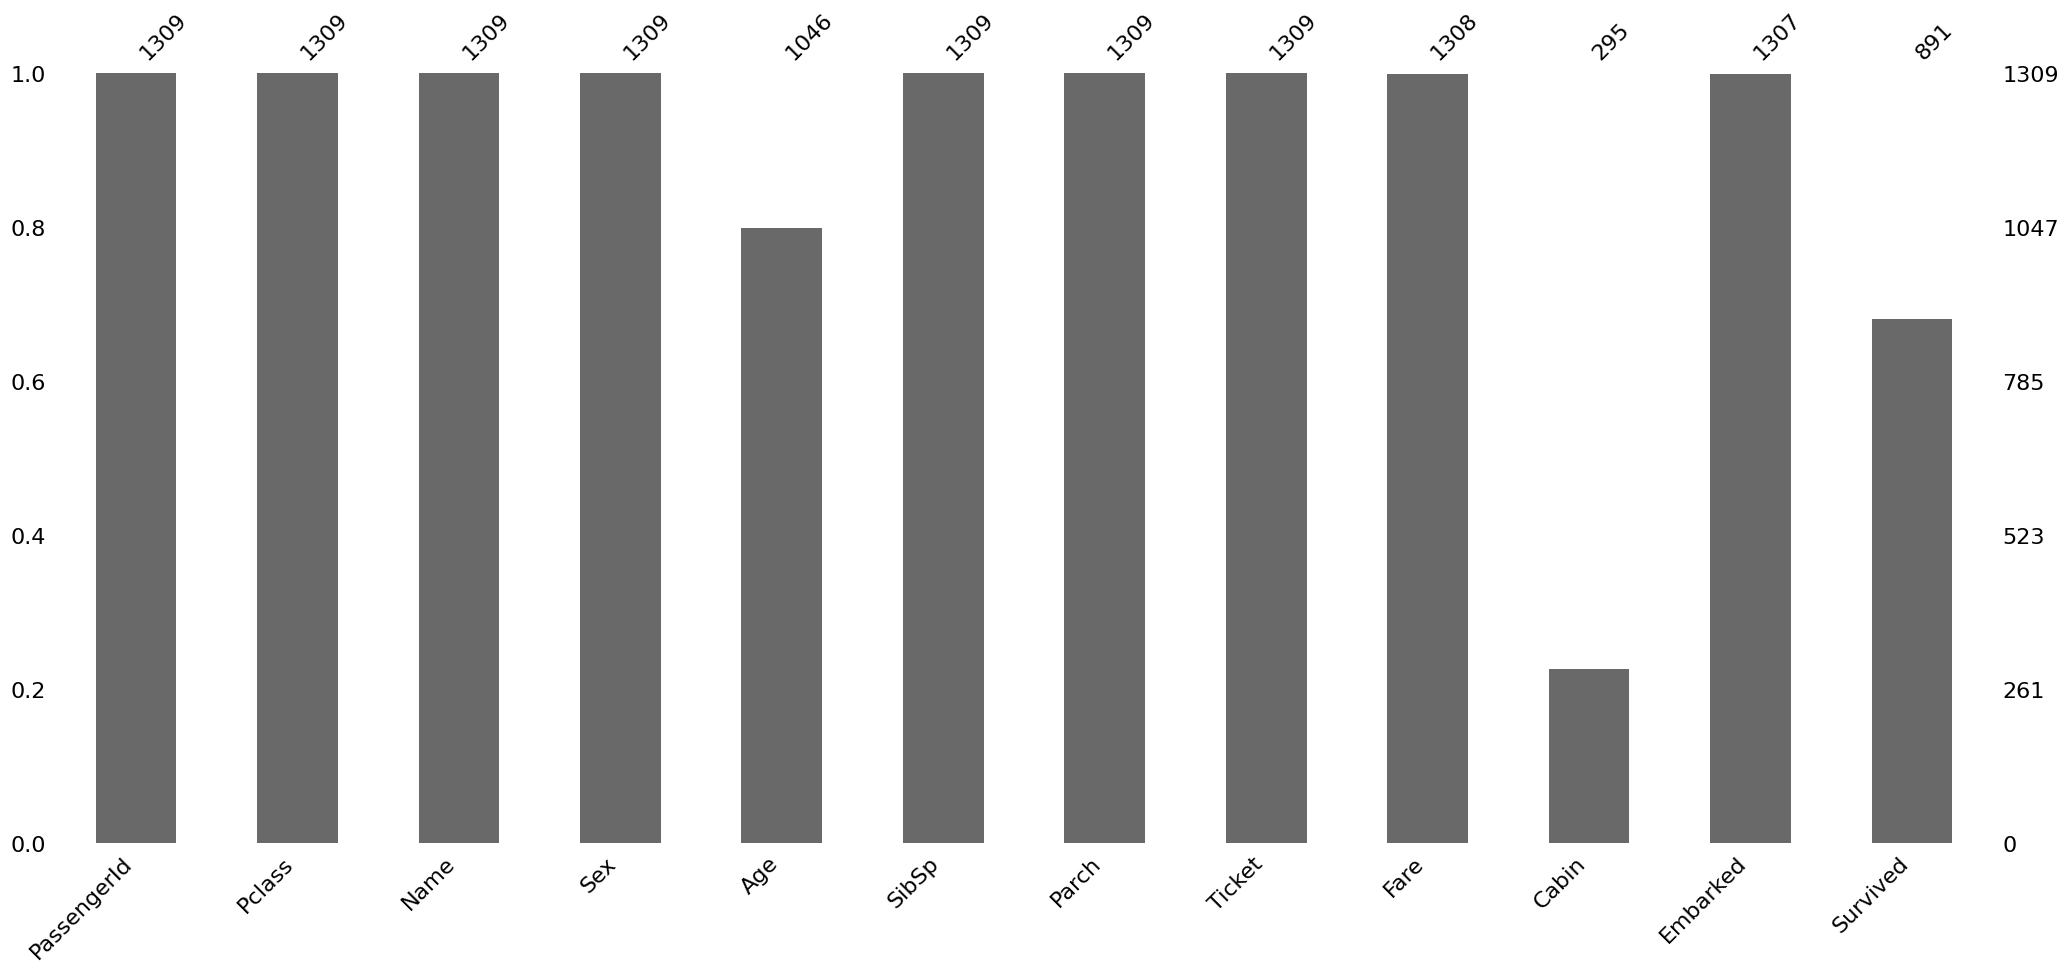

In [ ]:
msno.bar(df2)

In [ ]:
# Статистика пропусков
missing_stats = pd.DataFrame({
    'Колонка': df2.columns,
    'Пропусков': df2.isna().sum().values,
    'Доля (%)': (df2.isna().mean() * 100).round(1).values
}).sort_values('Доля (%)', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)
missing_stats

,Колонка,Пропусков,Доля (%)
0,Cabin,1014,77.5
1,Survived,418,31.9
2,Age,263,20.1
3,Embarked,2,0.2
4,Fare,1,0.1
5,Name,0,0.0
6,Pclass,0,0.0
7,PassengerId,0,0.0
8,Sex,0,0.0
9,Ticket,0,0.0


<Axes: >

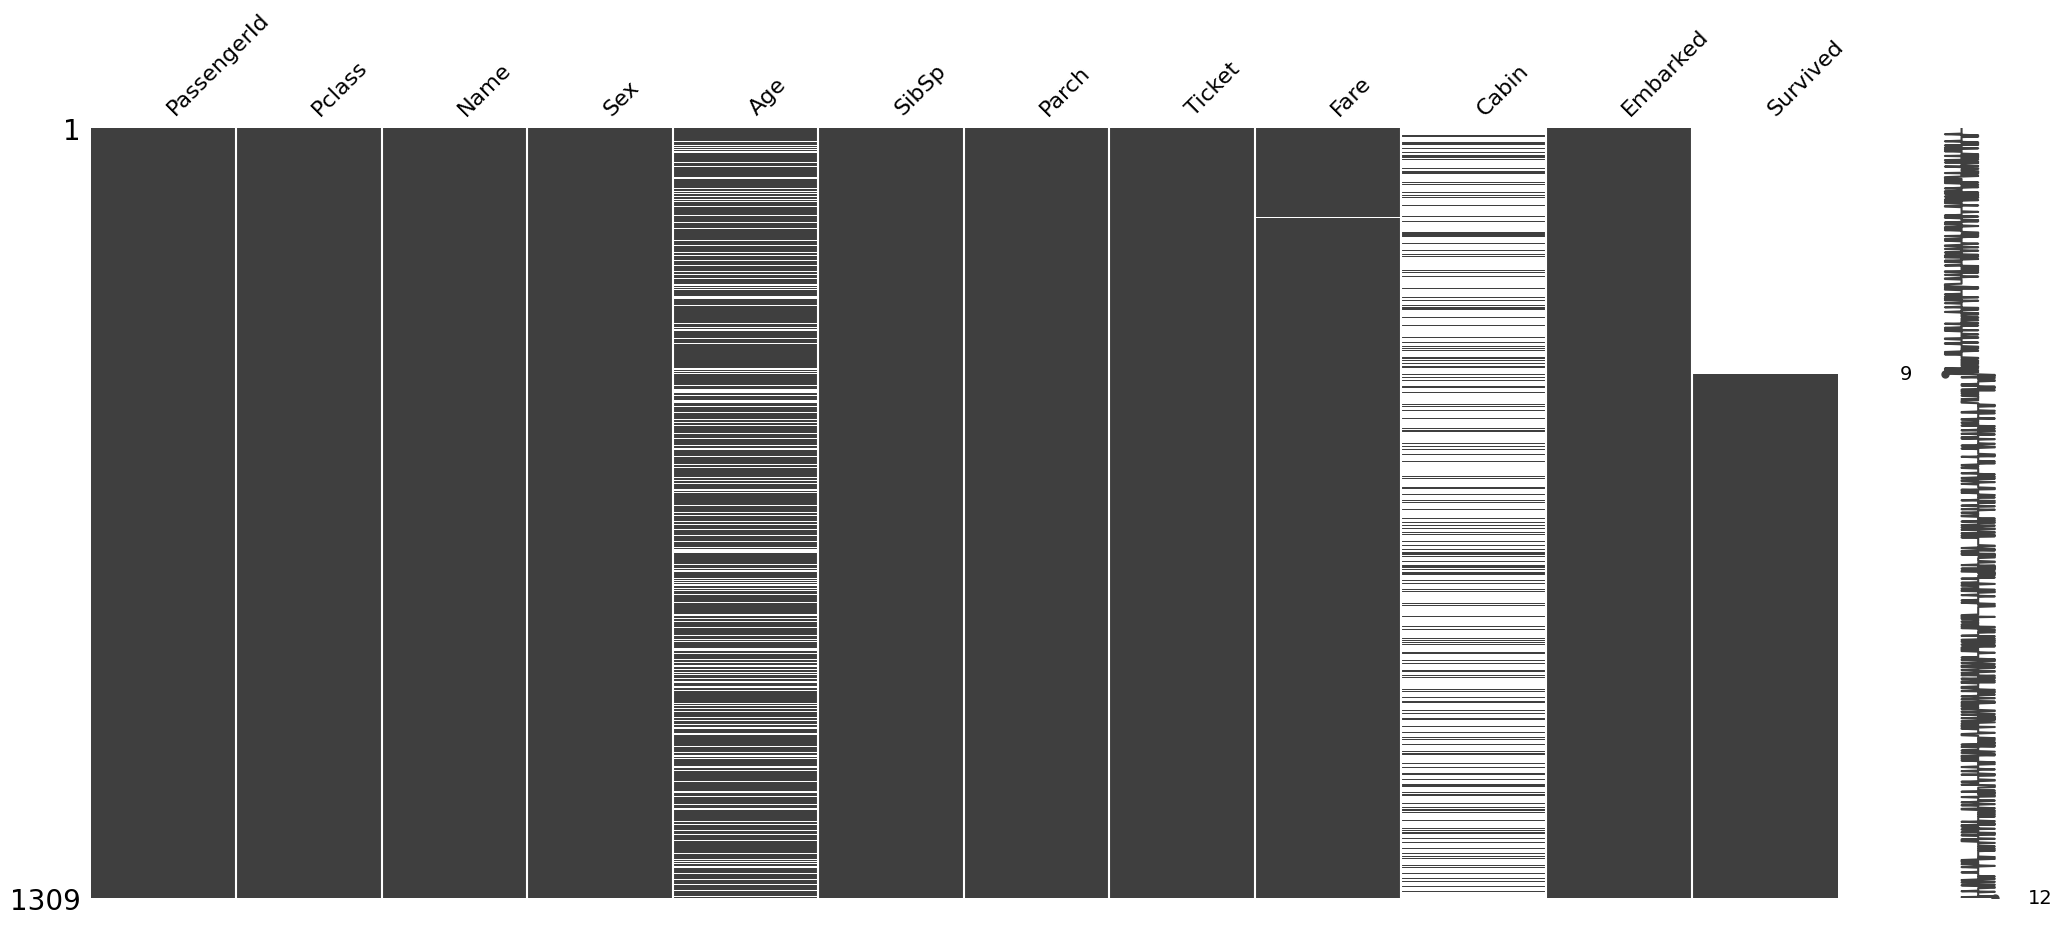

In [ ]:
msno.matrix(df2)

<Axes: >

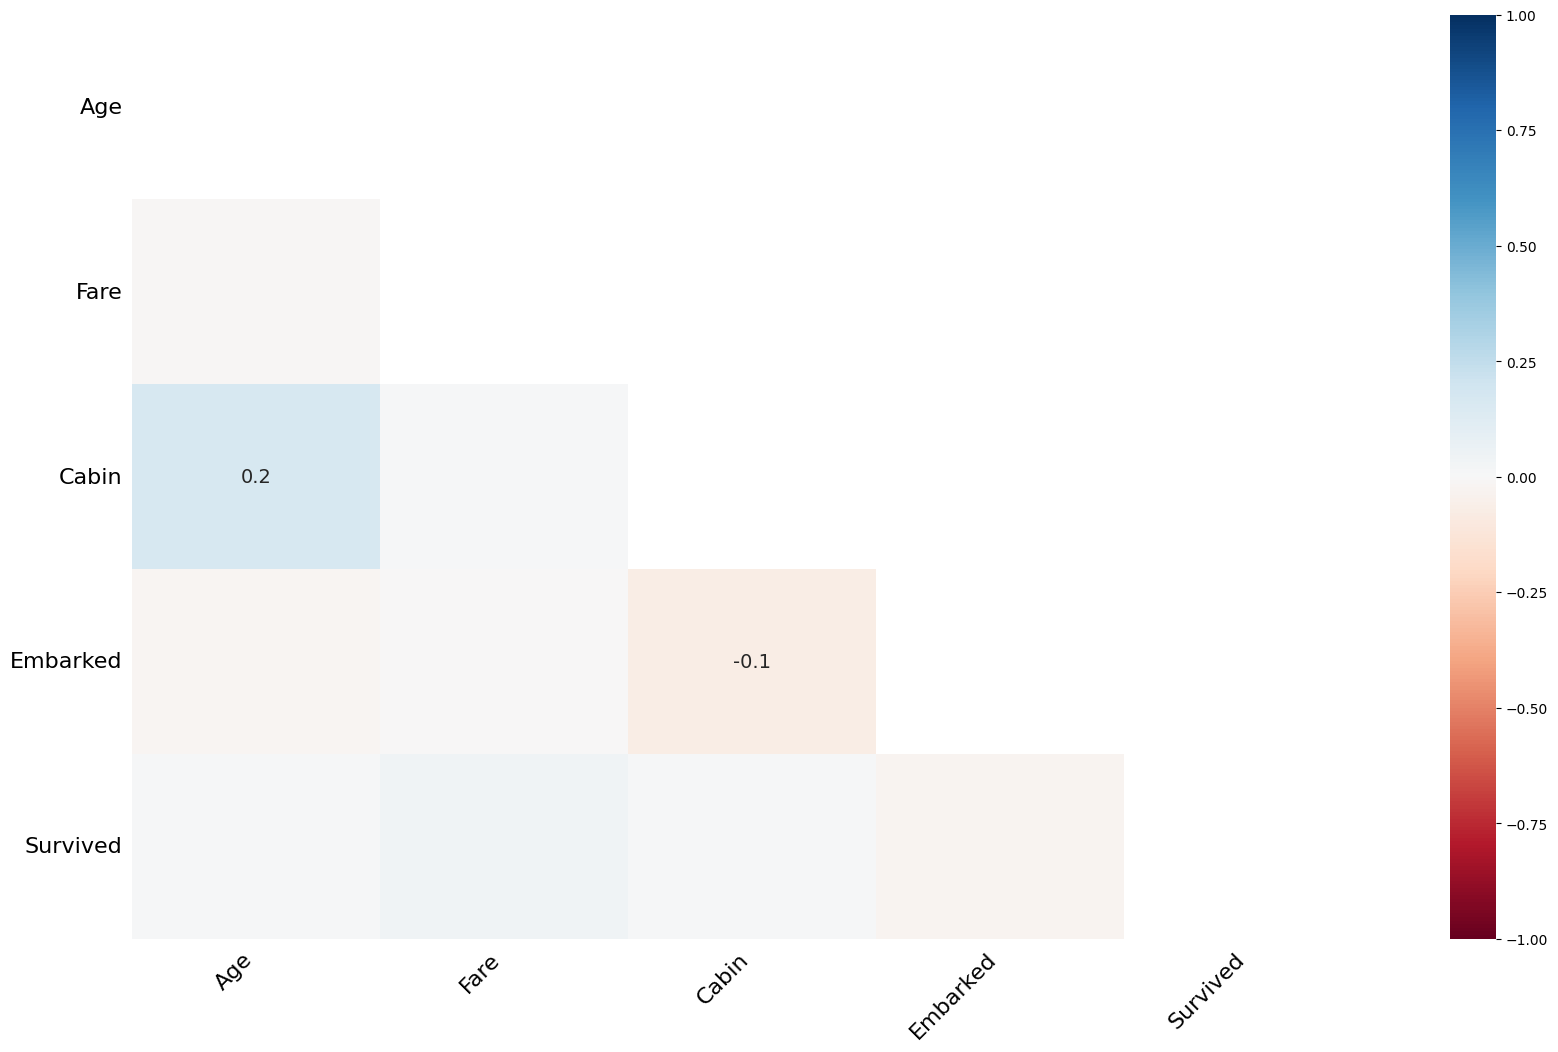

In [ ]:
msno.heatmap(df2)

In [ ]:
df2['Age_is_na'] = df2['Age'].isna()
df2['Fare_is_na'] = df2['Fare'].isna()
df2['Cabin_is_na'] = df2['Cabin'].isna()
df2['Survived_is_na'] = df2['Survived'].isna()

In [ ]:
df2

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,Age_is_na,Fare_is_na,Cabin_is_na,Survived_is_na
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,NaN,False,False,True,True
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,NaN,False,False,True,True
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,NaN,False,False,True,True
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,NaN,False,False,True,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,NaN,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0.0,False,False,True,False
1305,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1.0,False,False,False,False
1306,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0.0,True,False,True,False
1307,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1.0,False,False,False,False


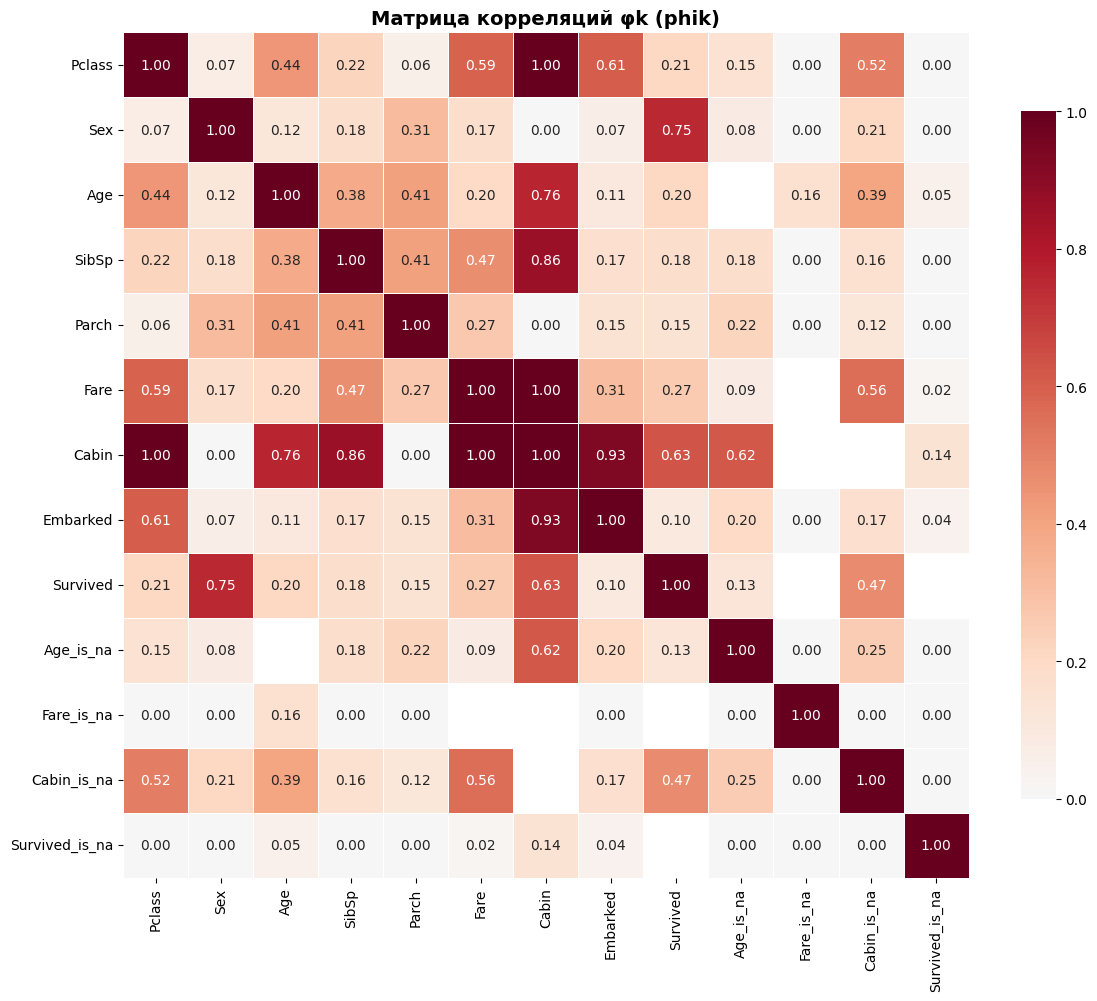

In [ ]:
interval_cols = ['Age',
    'Fare',
    ]

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = df2.drop(['PassengerId', 'Name', 'Ticket'], axis=1).phik_matrix(interval_cols=interval_cols, )

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df2['Age'] = df2.groupby(['Pclass', 'SibSp', 'Parch'], observed=True)['Age'].transform(lambda x: x.fillna(x.median()))

In [ ]:
df2= df2.dropna(subset = ('Fare', 'Embarked', 'Age'))
df2 = df2.drop(columns = 'Cabin')

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1292 entries, 0 to 1308
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PassengerId     1292 non-null   int64  
 1   Pclass          1292 non-null   int64  
 2   Name            1292 non-null   object 
 3   Sex             1292 non-null   object 
 4   Age             1292 non-null   float64
 5   SibSp           1292 non-null   int64  
 6   Parch           1292 non-null   int64  
 7   Ticket          1292 non-null   object 
 8   Fare            1292 non-null   float64
 9   Cabin           290 non-null    object 
 10  Embarked        1292 non-null   object 
 11  Survived        882 non-null    float64
 12  Age_is_na       1292 non-null   bool   
 13  Fare_is_na      1292 non-null   bool   
 14  Cabin_is_na     1292 non-null   bool   
 15  Survived_is_na  1292 non-null   bool   
dtypes: bool(4), float64(3), int64(4), object(5)
memory usage: 136.3+ KB


In [ ]:
df2['Parch'].value_counts()

Parch
0    1002
1     170
2     113
3       8
4       6
5       6
6       2
9       2
Name: count, dtype: int64

In [ ]:
k = [1, 2,3, 4]

In [ ]:
np.median(k)

np.float64(2.5)